In [107]:
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

import pickle

In [108]:
import json

with open('data.json') as f:
    data = json.load(f)

texts = []
labels = []

In [109]:
for intent in data['intents']:
    for pattern in intent['patterns']:
        texts.append(pattern)
        labels.append(intent['tag'])

In [110]:
import pandas as pd

df = pd.DataFrame({
    'text': texts,
    'label': labels
})

df.head()

,text,label
0,Hi,greeting
1,How are you?,greeting
2,Is anyone there?,greeting
3,Hello,greeting
4,Good day,greeting


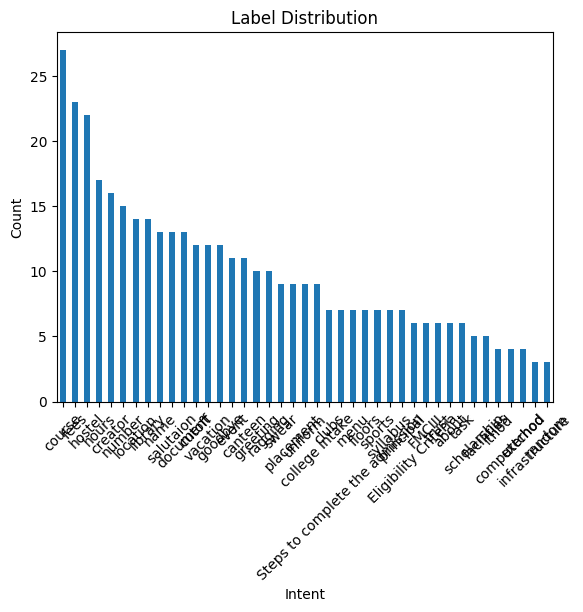

In [111]:
import matplotlib.pyplot as plt

plt.figure()
df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

In [112]:
df['text_length'] = df['text'].apply(len)

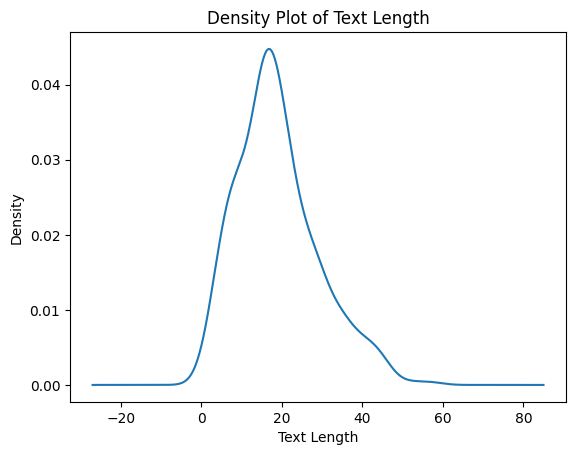

In [113]:
plt.figure()
df['text_length'].plot(kind='density')

plt.title("Density Plot of Text Length")
plt.xlabel("Text Length")

plt.show()

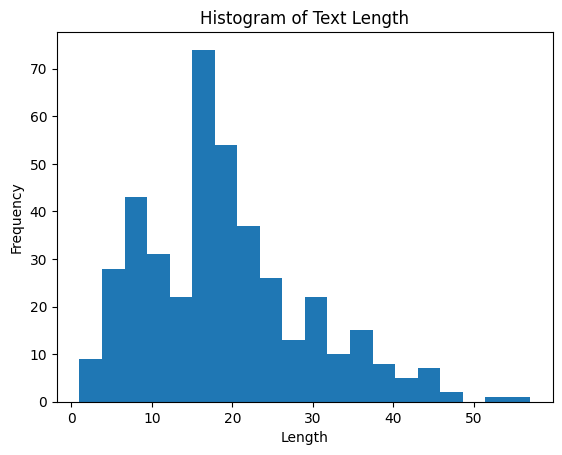

In [114]:
plt.figure()
plt.hist(df['text_length'], bins=20)

plt.title("Histogram of Text Length")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer

# convert text → numerical vectors
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['text'])
y = df['label']

print("Shape of X:", X.shape)

Shape of X: (408, 298)


In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 326
Testing samples: 82


In [117]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# create model
nb_model = MultinomialNB()

# train
nb_model.fit(X_train, y_train)

# predict
nb_pred = nb_model.predict(X_test)

# accuracy
nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc * 100)


Naive Bayes Accuracy: 42.68292682926829


In [118]:
from sklearn.linear_model import LogisticRegression

# create model
lr_model = LogisticRegression(max_iter=200)

# train
lr_model.fit(X_train, y_train)

# predict
lr_pred = lr_model.predict(X_test)

# accuracy
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc * 100)

Logistic Regression Accuracy: 54.87804878048781


In [119]:
from sklearn.svm import SVC

# create model
svm_model = SVC(kernel='linear')

# train
svm_model.fit(X_train, y_train)

# predict
svm_pred = svm_model.predict(X_test)

# accuracy
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc * 100)

SVM Accuracy: 65.85365853658537


In [120]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'SVM'],
    'Accuracy': [nb_acc * 100,  lr_acc * 100 , svm_acc * 100]
})

print(results)

                 Model   Accuracy
0          Naive Bayes  42.682927
1  Logistic Regression  54.878049
2                  SVM  65.853659


In [121]:
import json

accuracy_data = {
    "nb": nb_acc,
    "lr": lr_acc,
    "svm": svm_acc
}

with open("models/accuracy.json", "w") as f:
    json.dump(accuracy_data, f)

In [122]:
import pickle

pickle.dump(nb_model, open('models/nb.pkl', 'wb'))
pickle.dump(lr_model, open('models/lr.pkl', 'wb'))
pickle.dump(svm_model, open('models/svm.pkl', 'wb'))
pickle.dump(vectorizer, open('models/vectorizer.pkl', 'wb'))

In [123]:
import random

def get_response(user_input, model, vectorizer, data):
    # convert input → vector
    input_vec = vectorizer.transform([user_input])
    
    # predict intent
    tag = model.predict(input_vec)[0]
    
    # find matching response
    for intent in data['intents']:
        if intent['tag'] == tag:
            return random.choice(intent['responses'])

In [124]:
user_input = "What is admission process?"
response = get_response(user_input, nb_model, vectorizer, data)

print("Bot:", response)

Bot: Here are the fee structure details of the college : <br>FE fee structure : <a href="https://www.mmcoe.edu.in/images/FE2023-24.pdf" target="_blank"  rel="noopener noreferrer">FE FEES</a> <br>DSE fee structure : <a href="https://www.mmcoe.edu.in/images/DSE-2023-24.pdf" target="_blank"  rel="noopener noreferrer">DSE FEES</a> <br>Hostel and Mess FEES : <a href="https://www.mmcoe.edu.in/images/HOSTEL-2023-24.pdf" target="_blank"  rel="noopener noreferrer">HOSTEL AND MESS FEES</a>
